# Test Systems: A (Template) vs B (Enc-Dec) — Topic-Hard Split

Same evaluation as `test_systems.ipynb` but using the **topic-hard** split, where the dev/test sets contain headlines from topic clusters never seen during training.

| Metric | What it measures |
|---|---|
| **Anchor preservation** | Do named entities, numbers, etc. survive the rewrite? |
| **Semantic similarity** | Does the rewrite stay on topic? (sentence-transformer cosine sim) |
| **Classifier flip rate** | Does a trained classifier predict the *target* label on the rewrite? |

Each headline is rewritten in its natural direction:
- label=0 (neutral) → rewrite to sarcastic (**n2s**)
- label=1 (sarcastic) → rewrite to neutral (**s2n**)

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

print(f"Project root: {PROJECT_ROOT}")

Project root: E:\CS4248_Project


## 1. Load dev set (with anchors) — topic-hard split

In [2]:
SPLIT_NAME = "topic_hard"

df_all = pd.read_json("../artifacts/data/cleaned_with_anchors.jsonl", lines=True)

with open(f"../artifacts/splits/{SPLIT_NAME}.json", "r", encoding="utf-8") as f:
    split = json.load(f)

dev_ids = set(split["dev"])
dev_df = df_all[df_all["id"].isin(dev_ids)].copy().reset_index(drop=True)

print(f"Split: {SPLIT_NAME}")
print(f"Dev set: {len(dev_df)} rows")
print(f"  label=0 (neutral):   {(dev_df['label'] == 0).sum()}")
print(f"  label=1 (sarcastic): {(dev_df['label'] == 1).sum()}")
dev_df[["id", "text", "label"]].head()

Split: topic_hard
Dev set: 2774 rows
  label=0 (neutral):   1630
  label=1 (sarcastic): 1144


,id,text,label
0,sar_000010,lots of parents know this scenario,0
1,sar_000012,amanda peet told her daughter sex is 'a specia...,0
2,sar_000013,what to know regarding current treatments for ...,0
3,sar_000031,10 essential life lessons from a grandma,0
4,sar_000045,new history textbook makes hatred of history c...,1


## 2. Initialize systems and evaluation tools

In [3]:
from systems.system_a.system_a_template import SystemATemplate
from systems.system_b_encdec import generate_candidates as system_b_generate, batch_generate as system_b_batch
from systems.system_a.template_utils import preserves_anchors, get_anchor_texts
from similarity.semantic_similarity import semantic_similarity, batch_semantic_similarity

system_a = SystemATemplate()

print("System A (Template):  ready")
print("System B (Enc-Dec):   loading model on first call...")


def direction_for_label(label: int) -> str:
    return "n2s" if label == 0 else "s2n"


def target_label(label: int) -> int:
    return 1 if label == 0 else 0

System A (Template):  ready
System B (Enc-Dec):   loading model on first call...


## 3. Load the trained classifier (for flip-rate evaluation)

We use the LogReg model trained on the **topic-hard** split so the classifier matches the evaluation split.

In [4]:
import joblib

LOGREG_MODEL_PATH = PROJECT_ROOT / "artifacts" / "classifiers" / "logreg" / SPLIT_NAME / "model.joblib"
clf = joblib.load(LOGREG_MODEL_PATH)
print(f"Loaded classifier from {LOGREG_MODEL_PATH}")


def classify_text(text: str) -> tuple[int, float]:
    """Return (predicted_label, prob_sarcastic) for a single text."""
    prob = clf.predict_proba([text])[0, 1]
    return int(prob >= 0.5), float(prob)


test_pred, test_prob = classify_text("Nation relieved as experts confirm everything is fine")
print(f"Test: pred={test_pred}, prob_sarcastic={test_prob:.3f}")

Loaded classifier from E:\CS4248_Project\artifacts\classifiers\logreg\topic_hard\model.joblib
Test: pred=1, prob_sarcastic=0.878


## 4. Run both systems on the dev set

For each headline we collect: the best rewrite from each system, anchor preservation, semantic similarity, and classifier prediction on the rewrite.

> **Note:** System B uses Flan-T5 generation, so this cell takes a few minutes.

In [5]:
# ========== PHASE 1: collect rewrites ==========
# System A is template-based (instant), so run it in a fast loop.
all_texts = dev_df["text"].tolist()
all_labels = dev_df["label"].astype(int).tolist()
all_anchors = [row.get("anchors", {}) for _, row in dev_df.iterrows()]
all_directions = [direction_for_label(l) for l in all_labels]

print("Phase 1a · System A rewrites (template)...")
rewrites_a = [
    system_a.rewrite(t, a, d)
    for t, a, d in tqdm(zip(all_texts, all_anchors, all_directions),
                        total=len(all_texts), desc="System A")
]

# System B: batched GPU generation — much faster than one-by-one.
BATCH_SIZE = 16
n_batches = (len(all_texts) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Phase 1b · System B rewrites ({n_batches} batches, batch_size={BATCH_SIZE})...")

rewrites_b_lists = []
for i in tqdm(range(0, len(all_texts), BATCH_SIZE), total=n_batches, desc="System B (batched)"):
    chunk = system_b_batch(
        all_texts[i : i + BATCH_SIZE],
        all_directions[i : i + BATCH_SIZE],
        k=1, batch_size=BATCH_SIZE,
    )
    rewrites_b_lists.extend(chunk)
rewrites_b = [cands[0] for cands in rewrites_b_lists]

eval_df = pd.DataFrame({
    "id": dev_df["id"].tolist(),
    "label": all_labels,
    "direction": all_directions,
    "target_label": [target_label(l) for l in all_labels],
    "original": all_texts,
    "anchors": all_anchors,
    "rewrite_a": rewrites_a,
    "rewrite_b": rewrites_b,
})

print(f"Phase 1 done — {len(eval_df)} rewrites collected.")

# ========== PHASE 2: batch semantic similarity (GPU-accelerated) ==========
print("Phase 2 · computing semantic similarity (batched)...")
originals = eval_df["original"].tolist()
eval_df["sim_a"] = batch_semantic_similarity(originals, eval_df["rewrite_a"].tolist())
eval_df["sim_b"] = batch_semantic_similarity(originals, eval_df["rewrite_b"].tolist())
print("Phase 2 done.")

# ========== PHASE 3: batch classify + anchor check ==========
print("Phase 3 · classifier predictions + anchor checks...")
probs_a = clf.predict_proba(eval_df["rewrite_a"].tolist())[:, 1]
probs_b = clf.predict_proba(eval_df["rewrite_b"].tolist())[:, 1]

eval_df["prob_a"] = probs_a
eval_df["pred_a"] = (probs_a >= 0.5).astype(int)
eval_df["flip_a"] = (eval_df["pred_a"] == eval_df["target_label"]).astype(int)

eval_df["prob_b"] = probs_b
eval_df["pred_b"] = (probs_b >= 0.5).astype(int)
eval_df["flip_b"] = (eval_df["pred_b"] == eval_df["target_label"]).astype(int)

eval_df["anchor_ok_a"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_a"])
]
eval_df["anchor_ok_b"] = [
    preserves_anchors(a, r) for a, r in zip(eval_df["anchors"], eval_df["rewrite_b"])
]

print(f"All phases complete — {len(eval_df)} rows.")
eval_df.head()

Phase 1a · System A rewrites (template)...


System A:   0%|          | 0/2774 [00:00<?, ?it/s]

Phase 1b · System B rewrites (174 batches, batch_size=16)...


System B (batched):   0%|          | 0/174 [00:00<?, ?it/s]

Phase 1 done — 2774 rewrites collected.
Phase 2 · computing semantic similarity (batched)...
Phase 2 done.
Phase 3 · classifier predictions + anchor checks...
All phases complete — 2774 rows.


,id,label,direction,target_label,original,anchors,rewrite_a,rewrite_b,sim_a,sim_b,prob_a,pred_a,flip_a,prob_b,pred_b,flip_b,anchor_ok_a,anchor_ok_b
0,sar_000010,0,n2s,1,lots of parents know this scenario,"{'entities': [], 'numbers': [], 'capitals': []...",Experts confirm lots of parents know this scen...,.,0.953827,0.517277,0.777591,1,1,0.513161,1,1,True,True
1,sar_000012,0,n2s,1,amanda peet told her daughter sex is 'a specia...,"{'entities': [{'text': 'amanda', 'start': 0, '...",Experts confirm amanda peet told her daughter ...,peet told her son she wants them for themselve...,0.987982,0.744421,0.216981,0,0,0.277223,0,0,True,False
2,sar_000013,0,n2s,1,what to know regarding current treatments for ...,"{'entities': [], 'numbers': [], 'capitals': []...",what to know regarding current treatments for ...,Today it's about current efforts to protect Am...,0.994931,0.838405,0.532029,1,1,0.427511,0,0,True,True
3,sar_000031,0,n2s,1,10 essential life lessons from a grandma,"{'entities': [], 'numbers': [{'text': '10', 's...",10 essential life lessons from a grandma in st...,Every life taught in an article contains absol...,0.928742,0.692210,0.359530,0,0,0.501296,1,1,True,False
4,sar_000045,1,s2n,0,new history textbook makes hatred of history c...,"{'entities': [], 'numbers': [], 'capitals': []...",new history textbook makes hatred of history c...,Several schools are beginning efforts to adapt...,1.000000,0.580929,0.730617,1,0,0.275875,0,1,True,True


## 5. Aggregate metrics

In [6]:
def summarize_system(eval_df, suffix):
    """Summarize metrics for one system (suffix = '_a' or '_b')."""
    return {
        "Anchor preservation (%)": eval_df[f"anchor_ok{suffix}"].mean() * 100,
        "Semantic similarity (mean)": eval_df[f"sim{suffix}"].mean(),
        "Classifier flip rate (%)": eval_df[f"flip{suffix}"].mean() * 100,
    }


overall = pd.DataFrame({
    "System A (Template)": summarize_system(eval_df, "_a"),
    "System B (Enc-Dec)": summarize_system(eval_df, "_b"),
}).round(2)

print(f"=== OVERALL — {SPLIT_NAME} split (both directions combined) ===\n")
display(overall)

=== OVERALL — topic_hard split (both directions combined) ===



,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,63.34
Semantic similarity (mean),0.98,0.74
Classifier flip rate (%),28.70,37.85


In [7]:
print("=== BREAKDOWN BY DIRECTION ===\n")

for direction, label_name in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction]
    breakdown = pd.DataFrame({
        "System A (Template)": summarize_system(sub, "_a"),
        "System B (Enc-Dec)": summarize_system(sub, "_b"),
    }).round(2)
    print(f"\n--- {label_name}  ({len(sub)} headlines) ---")
    display(breakdown)

=== BREAKDOWN BY DIRECTION ===


--- Neutral → Sarcastic  (1630 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,62.27
Semantic similarity (mean),0.97,0.74
Classifier flip rate (%),35.40,19.82



--- Sarcastic → Neutral  (1144 headlines) ---


,System A (Template),System B (Enc-Dec)
Anchor preservation (%),100.00,64.86
Semantic similarity (mean),1.00,0.73
Classifier flip rate (%),19.14,63.55


## 6. Visualize comparison

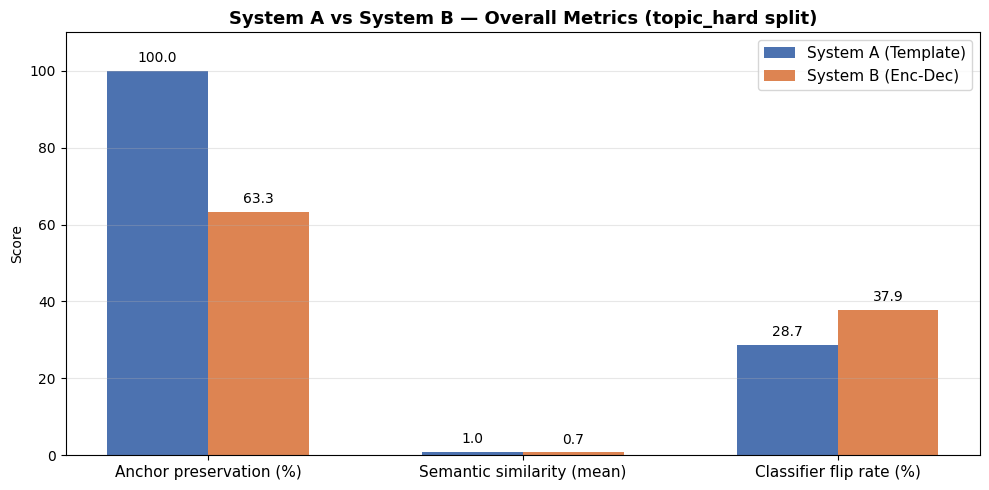

In [8]:
import matplotlib.pyplot as plt

metrics_names = list(overall.index)
sys_a_vals = overall["System A (Template)"].values
sys_b_vals = overall["System B (Enc-Dec)"].values

x = np.arange(len(metrics_names))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width / 2, sys_a_vals, width, label="System A (Template)", color="#4c72b0")
bars2 = ax.bar(x + width / 2, sys_b_vals, width, label="System B (Enc-Dec)", color="#dd8452")

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel("Score")
ax.set_title(f"System A vs System B — Overall Metrics ({SPLIT_NAME} split)", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

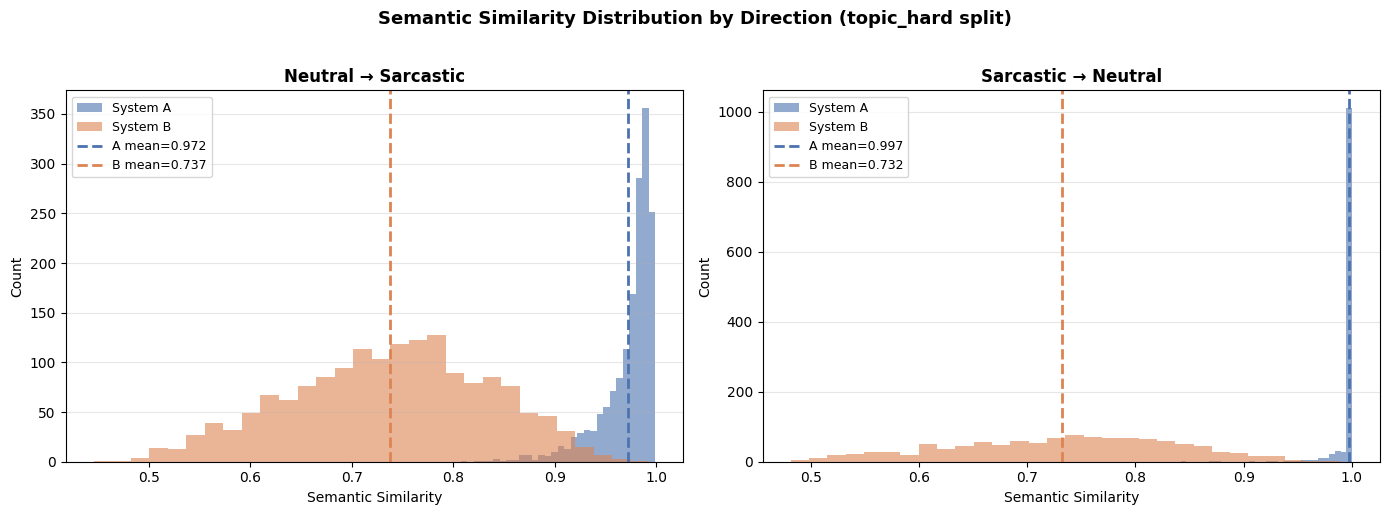

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (direction, title) in zip(axes, [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]):
    sub = eval_df[eval_df["direction"] == direction]

    sim_a = sub["sim_a"]
    sim_b = sub["sim_b"]

    ax.hist(sim_a, bins=30, alpha=0.6, label="System A", color="#4c72b0")
    ax.hist(sim_b, bins=30, alpha=0.6, label="System B", color="#dd8452")
    ax.axvline(sim_a.mean(), color="#4c72b0", linestyle="--", linewidth=2, label=f"A mean={sim_a.mean():.3f}")
    ax.axvline(sim_b.mean(), color="#dd8452", linestyle="--", linewidth=2, label=f"B mean={sim_b.mean():.3f}")
    ax.set_xlabel("Semantic Similarity")
    ax.set_ylabel("Count")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"Semantic Similarity Distribution by Direction ({SPLIT_NAME} split)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Sample rewrites (qualitative inspection)

Spot-check a few examples from each system and direction.

In [10]:
N_SAMPLES = 5

for direction, title in [("n2s", "Neutral → Sarcastic"), ("s2n", "Sarcastic → Neutral")]:
    sub = eval_df[eval_df["direction"] == direction].sample(N_SAMPLES, random_state=42)
    print(f"\n{'='*80}")
    print(f"  {title}")
    print(f"{'='*80}")

    for _, r in sub.iterrows():
        print(f"\n  ORIGINAL : {r['original']}")
        print(f"  SYSTEM A : {r['rewrite_a']}")
        print(f"    anchor={r['anchor_ok_a']}  sim={r['sim_a']:.3f}  flip={r['flip_a']}")
        print(f"  SYSTEM B : {r['rewrite_b']}")
        print(f"    anchor={r['anchor_ok_b']}  sim={r['sim_b']:.3f}  flip={r['flip_b']}")
        print(f"  {'-'*76}")


  Neutral → Sarcastic

  ORIGINAL : uber gave government millions of users' data
  SYSTEM A : Experts confirm uber gave government millions of users' data
    anchor=True  sim=0.981  flip=1
  SYSTEM B : uber made government get hundreds of million dollar ransom as they used users' photos to scam out the money.
    anchor=True  sim=0.864  flip=0
  ----------------------------------------------------------------------------

  ORIGINAL : don't march if you won't keep walking
  SYSTEM A : Experts confirm don't march if you won't keep walking
    anchor=True  sim=0.973  flip=0
  SYSTEM B : march don't do anything else to beat our opponent at marche, stop laughing all day, stop beating your enemy.
    anchor=True  sim=0.811  flip=0
  ----------------------------------------------------------------------------

  ORIGINAL : hot summer shows
  SYSTEM A : Experts confirm hot summer shows
    anchor=True  sim=0.929  flip=1
  SYSTEM B : summer sun doesn't work that big in summer and this year i

## 8. Verdict

In [11]:
print("=" * 60)
print(f"  SYSTEM COMPARISON SUMMARY  ({SPLIT_NAME} split)")
print("=" * 60)

for metric in metrics_names:
    va = overall.loc[metric, "System A (Template)"]
    vb = overall.loc[metric, "System B (Enc-Dec)"]
    winner = "A" if va > vb else ("B" if vb > va else "tie")
    print(f"  {metric:35s}  A={va:6.2f}  B={vb:6.2f}  → {'System ' + winner if winner != 'tie' else 'TIE'}")

print()

flip_a = eval_df["flip_a"].mean() * 100
flip_b = eval_df["flip_b"].mean() * 100

if flip_b > flip_a + 2:
    print("  System B (Enc-Dec) achieves a meaningfully higher flip rate,")
    print("  suggesting its generative rewrites are more effective at fooling")
    print("  the classifier. Check anchor preservation and similarity to see")
    print("  if it trades off faithfulness for this gain.")
elif flip_a > flip_b + 2:
    print("  System A (Template) achieves a higher flip rate despite being")
    print("  rule-based, which may indicate the classifier is sensitive to")
    print("  template-like sarcastic cues (prefixes/suffixes).")
else:
    print("  Both systems have similar flip rates. The choice may depend on")
    print("  semantic similarity and anchor preservation trade-offs.")

print("=" * 60)

  SYSTEM COMPARISON SUMMARY  (topic_hard split)
  Anchor preservation (%)              A=100.00  B= 63.34  → System A
  Semantic similarity (mean)           A=  0.98  B=  0.74  → System A
  Classifier flip rate (%)             A= 28.70  B= 37.85  → System B

  System B (Enc-Dec) achieves a meaningfully higher flip rate,
  suggesting its generative rewrites are more effective at fooling
  the classifier. Check anchor preservation and similarity to see
  if it trades off faithfulness for this gain.


## 9. Save sample conversions for human evaluation

Export a stratified random sample of rewrites for manual review. The CSV contains the original headline, both system rewrites, automatic scores, and blank columns for human ratings.

In [12]:
SAMPLE_N = 50
SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "human_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sample_frames = []
for direction in ["n2s", "s2n"]:
    subset = eval_df[eval_df["direction"] == direction]
    n = min(SAMPLE_N // 2, len(subset))
    sample_frames.append(subset.sample(n=n, random_state=SEED))

sample_df = pd.concat(sample_frames).sample(frac=1, random_state=SEED).reset_index(drop=True)

human_df = sample_df[[
    "id", "direction", "original",
    "rewrite_a", "sim_a", "flip_a", "anchor_ok_a",
    "rewrite_b", "sim_b", "flip_b", "anchor_ok_b",
]].copy()

human_df["human_fluency_a"] = ""
human_df["human_adequacy_a"] = ""
human_df["human_sarcasm_a"] = ""
human_df["human_fluency_b"] = ""
human_df["human_adequacy_b"] = ""
human_df["human_sarcasm_b"] = ""
human_df["human_preference"] = ""

out_path = OUTPUT_DIR / f"samples_{SPLIT_NAME}.csv"
human_df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(human_df)} samples -> {out_path}")
human_df.head()

Saved 50 samples -> E:\CS4248_Project\artifacts\human_eval\samples_topic_hard.csv


,id,direction,original,rewrite_a,sim_a,flip_a,anchor_ok_a,rewrite_b,sim_b,flip_b,anchor_ok_b,human_fluency_a,human_adequacy_a,human_sarcasm_a,human_fluency_b,human_adequacy_b,human_sarcasm_b,human_preference
0,sar_027999,n2s,'this was the xfl': examining television's gre...,'this was the xfl': examining television's gre...,0.987230,0,True,It only has 7 of these people.,0.506914,1,True,,,,,,,
1,sar_014817,s2n,study finds 80 percent of facial hair being si...,80 percent of facial hair being silently judge...,0.982866,0,True,Study warn: You should pay for your business a...,0.638940,1,False,,,,,,,
2,sar_011981,s2n,report: we don't make any money if you don't c...,we don't make any money if you don't click the...,0.944030,1,True,Reporter: You need help closing in: A report t...,0.674863,0,True,,,,,,,
3,sar_012804,s2n,"suicide bombing a cry for help, vengeance agai...","suicide bombing a cry for help, vengeance agai...",1.000000,1,True,Suicide killing a desperate plea for sympathy ...,0.720769,1,True,,,,,,,
4,sar_003995,n2s,are you making your guacamole right? here's ho...,are you making your guacamole right? here's ho...,0.992699,0,True,are you still making avocado right? here’s the...,0.721444,0,True,,,,,,,
